# 1-2회차 실습 | 펭귄 데이터로 규칙 만들기

아직 모델 배운 거 없음. 오늘은 눈이랑 손으로만 종을 맞춰봄.

목표는 정확도를 올리는 게 아니라, **어디서 막히는지** 직접 느껴보는 거임.


In [ ]:
##앞에 ! 대신 % 기호를 붙여 실행하면, 현재 노트북 커널이 구동 중인 정확한 파이썬 환경을 찾아가서 라이브러리를 강제로 설치해 줍니다)
%pip install scikit-learn 

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------------------------- ---- 7.3/8.3 MB 37.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 34.3 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -------- ------------------------------- 8.1/37.3 MB 39.2 MB/s eta 0:00:01
   ------------------- -------------------- 17.8/37.3 MB 42.8 MB/s eta 0:00:01
   ----------------------------- ---------- 27.3/37.3 MB 43.4 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 44.4 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 36.7 MB/s  0:00:01

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- --------------------------


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 변수 이름 규약 (문제 노트북 전용)

뒷부분은 앞에서 만든 변수를 그대로 가져다 씀.
**이름을 아래와 똑같이** 지을 것. 다르게 지으면 뒤에서 에러남.

| 만드는 곳 | 변수 이름 | 담기는 것 |
|-----------|----------|----------|
| Q4 | `meas` | 측정값 컬럼 4개의 이름 리스트 |
| Q4 뒤 | `peng` | 측정값 결측을 제거한 342마리 표 |
| Q5 | `baseline` | 기준선 정확도 (가장 많은 종의 비율) |
| Q7 | `colors` | 종별 색 딕셔너리 |
| Q9 | `my_rule`, `my_pred` | 내 규칙 함수 / 342마리 예측 결과 |
| Q10 | `is_correct`, `accuracy` | 맞았는지 여부 / 내 규칙 정확도 |
| Q10-2 | `wrong` | 틀린 개체만 모은 표 |
| Q11 | `peng_sex`, `base_sex` | 성별 결측까지 제거한 333마리 / 성별 기준선 |
| Q12 | `best_t`, `best_acc` | 최적 몸무게 임계값 / 그때 정확도 |
| Q14 | `X`, `y`, `model` | 특성 / 정답 / 트리 모델 |

> 헷갈리면 해설 노트북 변수 이름 그대로 따라 쓸 것.


---
## Part 0. 준비

Iris는 결측치도 없고 품종별 개수도 딱 50개씩 균등함. 너무 깨끗함.

그래서 오늘은 진짜 현실 데이터인 **펭귄(Palmer Penguins)** 데이터로 감.

- 측정 못 한 애들 있음 (결측치)
- 종별 개수 안 맞음 (불균형)
- 넣으면 점수는 오르는데 넣어도 되는지 애매한 컬럼도 있음


In [3]:
# 오늘 실습에서 쓸 도구들을 한 번에 불러옵니다.
import numpy as np              # 숫자 계산 (조건에 따라 값 고르기 등)
import pandas as pd             # 표 형태 데이터 다루기
import seaborn as sns           # 펭귄 데이터를 불러오는 용도로만 사용
import matplotlib.pyplot as plt # 그래프 그리기

# 버전을 기록해 둡니다. 나중에 결과가 다르게 나올 때 원인을 찾는 단서가 됩니다.
print(f"numpy      : {np.__version__}")
print(f"pandas     : {pd.__version__}")
print(f"seaborn    : {sns.__version__}")


numpy      : 2.5.1
pandas     : 3.0.5
seaborn    : 0.13.2


In [69]:
# 그래프 제목에 한글을 쓰면, 폰트가 없을 때 네모(□□□)로 깨집니다.
# 운영체제마다 한글 폰트 이름이 다르기 때문에, 있는 것을 자동으로 찾아 씁니다.
import matplotlib.font_manager as fm

# 후보 폰트: 맥 / 윈도우 / 리눅스(Colab) 순서
candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]

# 현재 컴퓨터에 설치된 폰트 이름을 모두 모읍니다.
installed = {f.name for f in fm.fontManager.ttflist}

# 후보 중 실제로 설치된 첫 번째 폰트를 선택합니다.
chosen = next((c for c in candidates if c in installed), None)

if chosen:
    plt.rcParams["font.family"] = chosen
    print(f"한글 폰트 설정 완료: {chosen}")
else:
    # 하나도 없으면 한글이 깨집니다. Colab이라면 아래 주석을 풀고 설치하세요.
    # !apt-get install -y fonts-nanum > /dev/null && fc-cache -fv
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 한글 폰트를 쓰면 축의 마이너스 기호가 깨지는 문제가 있어 함께 꺼 줍니다.
plt.rcParams["axes.unicode_minus"] = False


한글 폰트 설정 완료: Malgun Gothic


In [5]:
# seaborn에 내장된 예제 데이터 목록에서 펭귄 데이터를 가져옵니다.
# 주의: 이 함수는 인터넷에서 데이터를 내려받습니다.
#       오프라인이거나 회사망에서 막히면 아래 except 안내를 참고하세요.
try:
    peng_raw = sns.load_dataset("penguins")
    print("데이터 로드 성공")
except Exception as e:
    print("데이터를 내려받지 못했습니다:", e)
    print("penguins.csv 파일을 받아 같은 폴더에 두고 아래 줄을 쓰세요.")
    print('peng_raw = pd.read_csv("penguins.csv")')

# 앞의 5줄만 눈으로 확인합니다. 데이터를 만나면 항상 먼저 하는 일입니다.
peng_raw.head()


데이터 로드 성공


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### 컬럼 설명

| 컬럼 | 뜻 | 종류 |
|------|-----|------|
| `species` | 펭귄 종 (Adelie / Chinstrap / Gentoo) | 문자 |
| `island` | 관측된 섬 (Biscoe / Dream / Torgersen) | 문자 |
| `bill_length_mm` | 부리 길이 (mm) | 숫자 |
| `bill_depth_mm` | 부리 두께 (mm) | 숫자 |
| `flipper_length_mm` | 물갈퀴 길이 (mm) | 숫자 |
| `body_mass_g` | 몸무게 (g) | 숫자 |
| `sex` | 성별 (Male / Female) | 문자 |

오늘 맞출 정답(Target)은 `species`. 나머지 측정값 4개가 특성(Feature)임.


---
## Part 1. 데이터 정체 파악

### Q1. 데이터 크기 확인

몇 마리, 컬럼 몇 개인지 확인할 것.

**[예측]**
- 행 수: ______
- 열 수: ______


In [ ]:
# TODO: peng_raw 의 크기를 출력하세요.
# 힌트: .shape 속성을 사용합니다.

peng_raw.shape # --344, 7

(344, 7)

### Q2. 컬럼 타입 확인

문자 컬럼 vs 숫자 컬럼 구분하는 거임. 모델은 문자를 그대로 못 먹음.

**[예측]** 문자 컬럼 몇 개일 것 같음? ______


In [11]:
# TODO: 컬럼별 타입과 결측 상황을 한 번에 보세요.
# 힌트: .info() 를 호출합니다.
peng_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


### Q3. 결측치 개수 세기

**[예측]**
- `bill_length_mm`: ______
- `sex`: ______


In [29]:
# TODO: 컬럼별 결측치 개수를 세어 출력하세요.
# 힌트: .isnull() 뒤에 .sum() 을 붙입니다.

peng_raw.isnull().sum()


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [47]:
mask = peng_raw.isna().sum() > 0 #& ( peng_raw.columns != 'sex')
peng_raw.columns[mask]

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
       'sex'],
      dtype='str')

### Q4. 결측치 있는 행 직접 까보기

개수만 세면 놓치는 거 있음. 진짜로 그 행을 열어봐야 함.

**[예측]** 측정값 4개가 다 비어있는 애가 있을까, 아니면 하나씩만 비었을까?


In [49]:
# TODO: 측정값 4개가 모두 비어 있는 행을 찾아서 출력하세요.
# 힌트 1: 측정값 컬럼 이름을 리스트로 묶으면 편합니다.
#         meas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
# 힌트 2: peng_raw[meas].isnull().all(axis=1) 이 무엇을 돌려주는지 생각해 보세요.

display(peng_raw[peng_raw.isna().any(axis=1)] ) ## 결측치를 하나라도 갖고 있는 데이터 확인

# missing_columns = peng_raw.isna().sum().reset_index()
# meas = missing_columns[missing_columns.iloc[:, 1] > 0].iloc[:, 0].tolist()
meas = peng_raw.columns[peng_raw.isna().sum() > 0].tolist() ##결측치 컬럼 추출 to list
meas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'] ## 측정값으로 사용할 컬럼 
peng_raw[peng_raw[meas].isnull().all(axis=1)] ## 결측치가 발견된 컬럼들이 모두 컬측 데이터 인지 확인




,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


### 종 분류용 데이터 확정

측정값 기준으로만 결측 제거함.

In [50]:
# 종 분류용 데이터를 만듭니다.
# subset=meas -> 측정값 4개 중 하나라도 비면 그 행을 버립니다.
#                sex가 비어 있는 것은 신경 쓰지 않습니다.
peng = peng_raw.dropna(subset=meas).reset_index(drop=True)

print(f"원본        : {peng_raw.shape[0]}마리")
print(f"측정값 결측 제거 후: {peng.shape[0]}마리")
print(f"버린 펭귄   : {peng_raw.shape[0] - peng.shape[0]}마리")

# reset_index(drop=True) 는 행을 버리면서 생긴 번호 구멍을 다시 0부터 매겨 줍니다.


원본        : 344마리
측정값 결측 제거 후: 342마리
버린 펭귄   : 2마리


### Q5. species 분포 확인

**[예측]** 가장 많은 종은 전체의 몇 %일 것 같음? ______%


,species,count,ratio
0,Adelie,151,0.441520
1,Gentoo,123,0.359649
2,Chinstrap,68,0.198830


C:\Users\dsbang\AppData\Local\Temp\ipykernel_38412\411340885.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='species', y='count', data=df_summary, ax=ax1, palette='Blues_d', alpha=0.8)


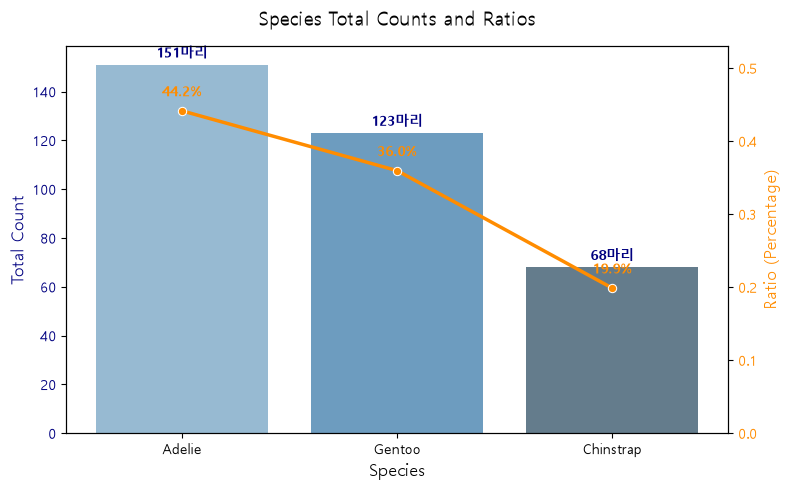

In [62]:
# TODO: 종별 개체 수와 비율을 출력하고, 막대그래프로 그리세요.
# 힌트 1: peng["species"].value_counts()
# 힌트 2: 비율은 value_counts(normalize=True)
# 힌트 3: 막대그래프는 plt.bar(x, y)

# peng["species"].value_counts())
# peng["species"].value_counts(normalize=True)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df_counts = peng['species'].value_counts().reset_index()

# sns.barplot(x='species', y='count', data=df_counts, palette='Set2')
# plt.title('Species Total Counts')
# plt.show()

# df_ratio = peng["species"].value_counts(normalize=True).reset_index()
# sns.barplot(x='species', y='ratio', data=df_ratio, palette='Pastel1')
# plt.title('Species Proportions')
# plt.show()

# 1. 데이터 준비 
# 개수와 비율 계산 후 하나의 데이터프레임으로 변환
counts = peng["species"].value_counts()
ratios = peng["species"].value_counts(normalize=True)

df_summary = pd.concat([counts, ratios], axis=1)
df_summary.columns = ['count', 'ratio']
df_summary = df_summary.reset_index()
display(df_summary)

# 2. 그래프 그리기 시작
fig, ax1 = plt.subplots(figsize=(8, 5))
# [왼쪽 Y축] 총합계 막대그래프
sns.barplot(x='species', y='count', data=df_summary, ax=ax1, palette='Blues_d', alpha=0.8)
ax1.set_title('Species Total Counts and Ratios', fontsize=14, pad=15)
ax1.set_xlabel('Species', fontsize=12)
ax1.set_ylabel('Total Count', color='navy', fontsize=12)
ax1.tick_params(axis='y', labelcolor='navy')
# [오른쪽 Y축] 비율 꺾은선그래프 (twinx 사용)
ax2 = ax1.twinx()
# marker를 추가하여 값의 위치를 명확히 표시합니다.
sns.lineplot(x='species', y='ratio', data=df_summary, ax=ax2, color='darkorange', marker='o', linewidth=2.5, sort=False)
ax2.set_ylabel('Ratio (Percentage)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')
# 오른쪽 Y축 범위를 0~1(또는 데이터에 맞게)로 고정하여 안정감 부여
ax2.set_ylim(0, df_summary['ratio'].max() * 1.2) 

# 3. 그래프 위에 실제 값 텍스트 표시하기 (선택 사항)
for i in range(len(df_summary)):
    # 막대 위 개수 표시
    ax1.text(i, df_summary['count'][i] + 3, f"{df_summary['count'][i]}마리", ha='center', color='navy', fontweight='bold')
    # 꺾은선 위 비율 표시
    ax2.text(i, df_summary['ratio'][i] + 0.02, f"{df_summary['ratio'][i]*100:.1f}%", ha='center', color='darkorange', fontweight='bold')

plt.tight_layout()
plt.show()

### Q6. 종별 측정값 평균 비교

**[예측]** 4개 측정값 중 종 구별에 제일 쓸모있어 보이는 거 하나 골라볼 것. 왜 그렇게 생각함?


In [65]:
# TODO: 종별 측정값 평균을 구하세요.
# 힌트: peng.groupby("species")[meas].mean()
# 여유가 있으면 .std() 로 표준편차도 함께 보세요.

display(peng.groupby("species")[meas].mean())
peng.groupby("species")[meas].std()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,2.663405,1.216650,6.539457,458.566126
Chinstrap,3.339256,1.135395,7.131894,384.335081
Gentoo,3.081857,0.981220,6.484976,504.116237


---
## Part 2. 눈으로 보기

### Q7. 산점도로 두 특성 동시에 보기

**[예측]** 세 종이 안 겹치고 갈라질 것 같음, 아니면 계속 겹칠 것 같음?


In [68]:
# TODO: 산점도 2장을 그리세요.
#   왼쪽 : x=bill_length_mm, y=bill_depth_mm
#   오른쪽: x=bill_length_mm, y=flipper_length_mm
#   두 그래프 모두 종(species)별로 색을 다르게 합니다.
#
# 힌트 1: fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# 힌트 2: 종별로 for 문을 돌면서 peng[peng["species"] == sp] 로 잘라 냅니다.
# 힌트 3: axes[0].scatter(x, y, label=sp) 처럼 그리고 마지막에 legend()

import matplotlib.pyplot as plt
import seaborn as sns

display(peng.groupby("species")[meas].std().reset_index())
df_std = peng.groupby("species")[meas].std().reset_index()
df_std.columns = ['species', 'std_value']

plt.figure(figsize=(6,4))
sns.stripplot(x='species', y='std_value', data=df_std, size=12)

#그래프 꾸미기
plt.title(f'Standard Deviation of {meas} by Species', fontsize=12, pad=15)
plt.xlabel('Species')
plt.ylabel('Standard Deviation (std)')
plt.grid(axis='y', linestyle='--', alpha=0.5) # 위치 비교를 돕는 가로 점선

plt.show()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,2.663405,1.216650,6.539457,458.566126
1,Chinstrap,3.339256,1.135395,7.131894,384.335081
2,Gentoo,3.081857,0.981220,6.484976,504.116237


ValueError: Length mismatch: Expected axis has 5 elements, new values have 2 elements

### (보조) 상자그림으로 4개 특성 한눈에 비교

상자가 안 겹치는 특성 = 그거 하나로 잘 갈라진다는 뜻임.


In [ ]:
# TODO: 4개 측정값 각각에 대해 종별 상자그림을 그리세요.
# 힌트 1: fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
# 힌트 2: 종별 값 모으기 -> peng.loc[peng["species"] == sp, col].values
# 힌트 3: axes[i].boxplot([...], tick_labels=[...])
#         (matplotlib 3.9 미만이면 tick_labels 대신 labels 를 쓰세요)



---
## Part 3. 내 규칙 만들기

### Q8. 한글로 먼저 설계 (키보드 금지)

측정값 보고 종 맞추는 규칙을 한글로 씀.

```
1단계: 만약 (   )가 (   )보다 (크면/작으면) -> (   ) 이다
2단계: 그렇지 않고 (   )가 (   )보다 (크면/작으면) -> (   ) 이다
3단계: 나머지는 -> (   ) 이다
```

**[내 설계]**
```
1단계:
2단계:
3단계:
```

**[예측]** 정확도 몇 % 나올 것 같음? ______%


### Q9. 한글 설계를 코드로 옮기기

| 한글 | 파이썬 |
|------|--------|
| 만약 ~라면 | `if ~:` |
| 그렇지 않고 ~라면 | `elif ~:` |
| 나머지는 | `else:` |
| ~이다 | `return ~` |


In [ ]:
# TODO: Q8에서 쓴 한글 설계를 함수로 옮기세요.

def my_rule(row):
    """펭귄 한 마리(row)를 받아 종 이름을 돌려주는 함수."""
    # 힌트: row["flipper_length_mm"] 처럼 값을 꺼냅니다.
    # if / elif / else 로 3단계를 만들고, 각각 return 하세요.
    pass


# TODO: 모든 행에 규칙을 적용해 my_pred 를 만드세요.
# 힌트: peng.apply(my_rule, axis=1)



### Q10. 채점하기

정확도 = 맞춘 개수 / 전체 개수

**[예측]** Q8에 적은 숫자 다시 옮겨 적을 것: ______%


In [ ]:
# TODO: 내 규칙의 정확도를 계산하세요.
# 힌트 1: (my_pred == peng["species"]) 가 무엇을 돌려주는지 생각해 보세요.
# 힌트 2: True/False 로 이루어진 줄에 .mean() 을 붙이면 True의 비율이 나옵니다.
# 힌트 3: 기준선(가장 많은 종의 비율)과 꼭 비교하세요.
#
# 이름 규약(뒤에서 다시 씁니다):
#   is_correct = 맞았는지 True/False
#   accuracy   = 정확도 숫자
#   baseline   = 기준선 숫자



### Q10-2. 틀린 애들은 누구임

**[예측]** 틀린 애들 중 어느 종이 제일 많을 것 같음? 왜 그렇게 생각함?


In [ ]:
# TODO: 틀린 개체만 골라내고, 실제 종별로 몇 마리씩 틀렸는지 세어 보세요.
# 힌트 1: is_correct 가 True/False 니까, 앞에 ~ 를 붙이면 반대가 됩니다.
# 힌트 2: peng[~is_correct] 로 틀린 행만 남깁니다.



In [ ]:
# TODO: 산점도 위에 틀린 개체를 빨간 동그라미로 표시하고,
#        내가 정한 경계선(206, 43)을 선으로 그려 보세요.
# 힌트 1: plt.axhline(206), plt.axvline(43) 으로 기준선을 그립니다.
# 힌트 2: facecolors="none", edgecolors="red" 를 주면 속이 빈 동그라미가 됩니다.



---
## Part 4. 벽

### Q11. 이번엔 성별 맞춰보기

방법은 똑같음. 그래프 보고, 규칙 만들고, 채점.

먼저 성별 결측 9마리는 제거함.

**[예측]** 성별 맞추기가 종 맞추기보다 쉬울 것 같음, 어려울 것 같음?
내 규칙은 몇 % 나올 것 같음? ______%


In [ ]:
# TODO: sex 결측을 제거한 peng_sex 를 만들고, 성별 분포와 기준선을 확인하세요.
# 힌트: peng.dropna(subset=["sex"]).reset_index(drop=True)



In [ ]:
# TODO: 성별로 색을 다르게 해서 산점도 2장을 그리세요.
#   왼쪽 : x=bill_length_mm, y=body_mass_g
#   오른쪽: x=flipper_length_mm, y=bill_depth_mm
# 힌트: Q7에서 쓴 코드에서 species 를 sex 로만 바꾸면 됩니다.



### Q12. 성별 규칙 만들고 채점하기

가장 단순한 규칙: "몸무게가 어느 값보다 크면 Male, 아니면 Female"

**[예측]** 기준값 얼마로 잡을 거임? ______g
그때 정확도는 몇 %일 것 같음? ______%


In [ ]:
# TODO: 몸무게 임계값을 3700, 4000, 4200, 4500 으로 바꿔 가며 정확도를 구하세요.
# 힌트: np.where(peng_sex["body_mass_g"] > threshold, "Male", "Female")



In [ ]:
# TODO: 2500g ~ 6500g 을 25g 간격으로 전부 시도해서
#        가장 정확도가 높은 임계값을 찾고, 그래프로 그리세요.
# 힌트 1: thresholds = np.arange(2500, 6500, 25)
# 힌트 2: for 문으로 정확도를 리스트에 모읍니다.
# 힌트 3: np.array(리스트).argmax() 가 최댓값의 위치를 알려 줍니다.



### Q12-2. 조건 늘려보기 (선택)

종마다 크기 기준이 다르다는 거 Q11에서 봤음. 그럼 종별로 임계값 따로 잡으면 어떻게 될까.


In [ ]:
# TODO: 종별로 최적 몸무게 임계값을 따로 찾고, 전체 정확도를 구하세요.
#        그리고 계산을 몇 번 했는지 세어 보세요.
# 힌트: for 문 안에 for 문을 넣습니다. (종 3개) x (임계값 160개)



### Q13. 점수 올려주는 수상한 컬럼

`island`(섬) 아직 안 씀. 이거 넣으면 점수 오를까?

**[예측]** 섬 정보만으로 종 맞추면 정확도 몇 %일 것 같음? ______%


In [ ]:
# TODO: island 와 species 의 교차표를 만드세요.
# 힌트: pd.crosstab(peng["island"], peng["species"])



In [ ]:
# TODO: 1) 섬 정보만으로 종을 예측하는 규칙을 만들고 정확도를 구하세요.
#        2) Q9의 my_rule 앞에 섬 조건을 하나 얹어서 정확도가 오르는지 보세요.
# 힌트: np.where 를 겹쳐 쓰거나, if 문으로 함수를 새로 만들면 됩니다.



---
## Part 5. 벽 앞에서 (다음 시간 맛보기)

오늘 정확도는 잘 나왔을 거임. 근데 대답 못 하는 질문들이 몇 개 남았을 거임.
그 질문들 들고 다음 파트로 감.


### Q14. 마지막 3줄 (다음 시간 맛보기)

```python
model = DecisionTreeClassifier(max_depth=2)
model.fit(X, y)
model.score(X, y)
```

지금은 이해 안 해도 됨. 숫자만 볼 것.

**[예측]** 이 3줄이 만든 규칙, 내 규칙이랑 비슷할까 완전 다를까?


In [ ]:
# TODO: 아래 3줄을 그대로 실행해 보세요. 지금은 이해하지 않아도 됩니다.
# from sklearn.tree import DecisionTreeClassifier, export_text
# X = peng[meas]
# y = peng["species"]
# model = DecisionTreeClassifier(max_depth=2, random_state=42)
# model.fit(X, y)
# print(model.score(X, y))



In [ ]:
# TODO: 트리가 만든 규칙을 글자로 출력하세요.
# 힌트: print(export_text(model, feature_names=meas))



### Q14-2. 깊이 제한 풀면?

**[예측]** 정확도 몇 %까지 올라갈 것 같음? ______%


In [ ]:
# TODO: max_depth 를 1, 2, 3, 4, None 으로 바꿔 가며 정확도를 구해 표로 정리하세요.
# 힌트: for 문 안에서 모델을 새로 만들고 fit -> score



---
## 오늘 정리

빈칸 채워볼 것.

| 방법 | 정확도 |
|------|--------|
| 기준선 (전부 Adelie) | 44.15% |
| 내 규칙 | ______% |
| 내 규칙 + island | ______% |
| 트리 (depth=2) | ______% |
| 트리 (깊이 제한 없음) | ______% |


